## FINANCIAL ECONOMETRICS
MODULE 7 | LESSON 3

---

# **GRANGER CAUSALITY AND NETWORK THEORY**

|  |  |
|:---|:---|
|**Reading Time** |60 minutes|
|**Prior Knowledge** |OLS, Covariance Matrix, VAR model, Basic Network Theory, Basic Python|
|**Keywords** |Association, Causality, Granger Causality|
|  |  |

## **1. Introduction**
In the last lesson, we frequently discussed how one variable influences another variable in a network. In this lesson, we are going to go one step further and discuss various types of relationships among variables. We will first introduce the concept of association among variables and its characteristics. Next, we will give a short explanation about causality. Then we will introduce Granger causality and explain its assumptions and limitations. We will also provide some Granger causality application examples. Finally, we will show how to combine Granger causality with networks to analyze relationships among time series.

## **2. Association Versus Causality**
### **2.1. Understand Association**
**Association** or **correlation** is used to describe the statistical relationship or pattern of two time series (Nicolae et al, 2022). The correlation coefficient of two time series tells us the strength of the linear association of the two time series.
<br>
<br>
Some important properties of the association are listed as follows:
1. The relationship is symmetric, which means if X is associated with Y, Y is also associated with X
2. Association does not indicate if one variable influences or has direct connection to the other variable. We also call it non-directional
3. Association can exist even if two variables do not have a direct causal connection
4. Association can be measured using correlation coefficients

If the correlation coefficient shows that two time series are highly associated (correlated), our next question tends to be: does one time series  cause the other? There can be two possible causal scenarios:

1. Direct Causation: change in variable X causes a change in variable Y (or vice-versa)
2. Common response: variable X and variable Y are influenced by variable Z

We can use the network graph we learned in the last lesson to demonstrate the two scenarios.
<br>
<br>
**Figure 1. Network Graph for Causal Types of Association**
<br>
![M7_L2_network_graph](M7L2_causation%20and%20confounder.jpg)
<br>
<br>
From Figure 1, we can see the Direct Causation situation on the left is the most straight forward causal relationship. The Common Response situation on the right is the same as the complicated case we had with a confounding variable C in the last lesson. When a confounding variable is not included in a model, the model result will create a spurious association. To eliminate a spurious (false) association between A and B, researchers should identify and control for confounding variables.

### **2.2. Understand Causality**
**Causality** means that one variable directly influences or produces changes in another (Hansen, 2014). Causal Inference is the method to analyze actual cause-and-effect relationship among variables.
<br>
A variable $x_{1}$ is considered to have a causal influence on the outcome variable $y$ if changing $x_{1}$ leads to a change in $y$, assuming all other variables remain fixed. The complete model for the outcome can be expressed as:
$$y = h(x_1, x_2, u)$$

where $x_{1}$ and $x_{2}$ are observable inputs,
<br>
$u$ is an unmeasured random component,
<br>
$h$ describes the functional relationship among these elements.
<br>
<br>
The causal effect of $x_1$ is defined as the rate of change in $y$ with respect to $x_1$, while keeping $x_2$ and $u$ constant:
$$C(x_1, x_2, u) = \nabla_1 h(x_1, x_2, u)$$

where $\nabla_1$ is the partial derivative with respect to $x_1$.
<br>
Here are the key properties of causality:
<br>
1. Causality represents an asymmetric relationship, which means if X causes Y, it doesn't indicate that  Y necessarily causes X.
2. Causality shows which variable influences the other -- therefore it is directional.
3. Causality is sequential, which means cause precedes effect
4. There is a mechanism to make influence happen
<br>


### **3. Granger Causality**
#### **3.1. Introduction**
In the last section, we discussed association and causality. In this section, we are going to introduce another related method to analyze the relationship of two time series - Granger Causality. **Granger Causality** is a framework introduced by Granger (1969) to access if the past values of one time series can predict the other time series. For example, Granger causality is used to check if the historical values of $x_t$ is predictive of $y_t$. If the answer is yes, we say $x$ Granger causes $y$. Granger causality leverages the time indexing feature that there is an ordering of values in a time series to study cause-and-effect relationship for time series.
<br>
One thing we need to be careful is even if $x$ Granger causes $y$ this does not necessarily mean that $x$ directly causes $y$. Granger causality is different from the causality we discussed in the last section. Granger causality focuses more on using the history of one variable to predict another variable and not actual cause-and-effect analysis.
<br>
Researchers have been using Granger causality to find out interactions among variables in finance and macroeconomics. For example, Billio et al (2012) used Granger causality to understand the connectivity and systemic risk of financial institutions. However, there are limitations about Granger causality to provide causal information among time series. We will discuss these limitations in the later part of this section. First, let's give a formal description of Granger Causality.
#### **3.2. Concept of Granger Causality**
We have two **stationary** time series $x_t$ and $y_t$. With these two time series, we can define the following two information sets:
$$\mathcal{H}_{1,t}=(y_{t},y_{t-1},y_{t-2},...)$$
$$\mathcal{H}_{2,t}=(y_{t},x_{t},y_{t-1},x_{t-1},y_{t-2},x_{t-2},...)$$
<br>
where information set $\mathcal{H}_{1,t}$ includes information from $y_t$ only and information set $\mathcal{H}_{2,t}$ includes information from both $y_t$ and $x_t$.
<br>
<br>
We say $x$ 'Granger causes' $y$ if
<br>
$$var[y_t - \mathcal{P}(y_t|\mathcal{H_{2,t-1}})]\lt var[y_t - \mathcal{P}(y_t|\mathcal{H_{1,t-1}})]\quad\quad\quad\quad(1)$$
<br>
where $\mathcal{P}(y_t|\mathcal{H_{2,t-1}})$ is the optimal prediction of $y_t$, given the information set $\mathcal{H_{2,t-1}}$ and $\mathcal{P}(y_t|\mathcal{H_{1,t-1}})$ is the optimal prediction of $y_t$, given the information set $\mathcal{H_{1,t-1}}$
<br>
<br>
Equation $(1)$ says when the variance of prediction errors of $y_t$ given information set $\mathcal{H_{2,t-1}}$ is smaller than the variance of prediction errors of $y_t$ given information set $\mathcal{H_{1,t-1}}$, the time series $x$ Granger causes $y$. It means the addition of past values of $x_t$ in the model improves the prediction of $y_t$ and reduces the variance of prediction errors.
<br>
Based on the above framework, how can we implement the actual Granger causality test? We can start by writing down the following two OLS regression models:
<br>
<p align="left">(reduced model)&nbsp;&nbsp;$y_t=\alpha_0+\alpha_1y_{t-1}+\alpha_2y_{t-2}...+\alpha_py_{t-p}+\epsilon_{t(\mathcal{H}_1)}\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad(2)$</p>
<p align="left">(full model)&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;$y_t=\alpha_0+\alpha_1y_{t-1}+\alpha_2y_{t-2}...+\alpha_py_{t-p}+\beta_1x_{t-1}+\beta_2x_{t-2}...+\beta_px_{t-p}+\epsilon_{t(\mathcal{H}_2)}\quad\quad\quad(3)$</p>
where  $\alpha_i$  are coefficients of  $y_i$  and  $\beta_j$  are coefficients of  $x_j$  while  $i,j\in[1,2,...,p]$
<br>
$\epsilon_{t(\mathcal{H_{1}})}$ is the white noise for the reduced model
$\epsilon_{t(\mathcal{H_{2}})}$  is the white noise for the full model

Equation  $(2)$  represents the model that only uses the past values of $y$ to predict  $y_t$  while equation  $(3)$  represents the model that uses not only the past values of  $y$  but also the past values of  $x$  to predict  $y_t$ . Equation  $(2)$  uses information set  $\mathcal{H_{1}}$  hence this model is a reduced model only using partial information. Equation  $(3)$  uses information set  $\mathcal{H_{2}}$  therefore this model is a full model using full information.
To check if  $x$  Granger causal to (or Granger causes)  $y$ , we can write down the following hypothesis testing:

$$H_0:\beta_1=\beta_2=...=\beta_p=0$$
<br>
$$H1:\text{at least one of the }\beta s\neq0 $$
<br>
To test the above hypothesis, we will use  $F$-test. Our test statistic is as follows:
<br>
<br>
$$F=\frac{(RSS_{reduced}-RSS_{full})/(r-s)}{(RSS_{full})/(T-r)}$$
<br>
where  $RSS$ is residual sum of squares of the regression model
<br>
$r$  is the number of parameters in the full model
<br>
$s$ is the number of parameters in the reduced model
<br>
$T$ is the number of samples

If the $p$ value of the  $F$-test is less than 5% given the significance level is set at 5%, we can reject the null hypothesis($H_0$) and say  $x$  Granger causes $y$. We will then switch the role of $x$ and $y$ to repeat the above said procedure to check if $y$ Granger causes $x$.

#### **3.3. Vector Autoregression Model(VAR) and Granger Causality**
In the last section, we described the detailed process of how to test if $x$ Granger causes $y$ and then used the same process to test if $y$ Granger-causes $x$. Many times, we can present the last two Granger causality tests in a bivariate VAR(p) framework. Let's first write down a VAR model for $x$ and $y$ with lag of $p$.
<br>
<br>
$$x_t=\phi_0+\phi_1x_{t-1}+\phi_2x_{t-2}...+\phi_px_{t-p}+\theta_1y_{t-1}+\theta_2y_{t-2}...+\theta_py_{t-p}+\varepsilon_{t}\quad\quad\quad(4)$$
$$y_t=\alpha_0+\alpha_1y_{t-1}+\alpha_2y_{t-2}...+\alpha_py_{t-p}+\beta_1x_{t-1}+\beta_2x_{t-2}...+\beta_px_{t-p}+\epsilon_{t}\quad\quad\quad(5)$$
<br>
<br>
Then we estimate this VAR($p$) model. Once we have the coefficient estimates of the model, we can conduct a Granger causality test. For example, if we want to test whether $x$ Granger causes $y$, it is equal to test $H_0: \beta_1=\beta_2=...=\beta_p$. If we want to test whether $y$ Granger causes $x$, it is equal to test $H_0:\theta_1=\theta_2=...=\theta_p=0$.
<br>
Another reason we will use VAR($p$) framework for Granger causality test is the selection of the number of lags $p$. That leads to our next topic: the assumptions of Granger causality.
#### **3.4. Assumptions and Limitations of Granger Causality**
Now you have seen how to set up a test for Granger causality for two time series. You might also have seen a few assumptions you used during the description of the process. Let's summarize the key assumptions here.
<br>
<br>
**Stationarity**
<br>
The two time series need to be stationary before applying Granger causality test. We can use the Augmented Dickey-Fuller (ADF) test to check for stationarity for the time series. If any time series is not stationary, we can apply the methods we learned from previous lessons to transform the time series.
<br>
**Linearity**
<br>
Granger causality test assumes the time series are in a linear relationship.
<br>
**Continuous-Valued Time Series**
<br>
The values of the time series for Granger causality test need to be continuous.
<br>
**No Confounding Variables**
<br>
All relevant variables are observed and included in the analysis and there are no unmeasurable variables.
<br>
**Lag is known**
<br>
The lag for the dependent past observations is known and uniform across all variables.
<br>
<br>
The linear dependency of the time series assumption can be restrictive as many time series data have a non-linear relationship. The no-confounding variables assumption is unrealistic especially for the bivariate model we having been discussing. We talked about the problem of excluding confounding variables in the model in the last lesson. We will demonstrate this issue when we show the Granger causality and network combination example. As for the known lag assumption, we can use the lag order selection function in the VAR model to decide the optimal lag for Granger causality test.
<br>
#### **3.5. An Example for Granger Causality Test in Bivariate VAR model**
In this section, let's try to run Granger causality for just two time series. We will pick the returns of JPMorgan stock and the Technology ETF for this example. As discussed in the last section, we need to check for stationarity of these two time series before conducting Granger causality test. We will use the ADF test to check for stationarity.


In [3]:
pip install networkx yfinance seaborn --upgrade


[notice] A new release of pip available: 22.3.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import yfinance as yf
import warnings
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.api import VAR

warnings.filterwarnings("ignore")

In [6]:
# Gather stock data and factor data for 7 years

# List of assets (stocks)
assets = ['AAPL',   # Apple
          'WMT',    # Walmart
          'AMZN',   # Amazon
          'GOOGL',  # Google
          'JPM',    # JP Morgan
          'WBD',    # Warner Brothers
          'GE']     # General Electric Co.

# List of factors
factors = [
    '^GSPC',   # S&P 500 (market factor)
    'XLF',     # Financial Select Sector SPDR Fund
    'XLK',     # Technology Select Sector SPDR Fund
    'SHY',     # Short-term Treasury ETF (interest rate factor)
    'DX-Y.NYB' # US Dollar index
]

# Combine assets and factors
tickers = assets + factors

# Download data
data = yf.download(tickers, start="2018-01-01", end="2024-12-31", auto_adjust=False)['Adj Close']

# Calculate returns
returns = data.pct_change().dropna()

# Add meaningful labels
returns.columns = [
    'Apple', 'Amazon', 'USD', 'GE', 'Google', 'JPMorgan', 'Treasury', 'Warner-Bro', 'Walmart', 'Financial', 'Technology', 'SP500'
]

[*********************100%***********************]  12 of 12 completed


In [7]:
# Standardize data
standardized_returns = (returns - returns.mean()) / returns.std()

In [8]:
# Perform the ADF test for JPMorgan stock return
jp_result = adfuller(returns['JPMorgan'])

print('p-value of JPMorgan: %f' % jp_result[1])

p-value of JPMorgan: 0.000000


In [9]:
# Perform the ADF test for Technology ETF
tech_result = adfuller(returns['Technology'])

print('p-value of Technology: %f' % tech_result[1])

p-value of Technology: 0.000000


From the results of the above augmented Dickey Fuller tests, both time series are stationary. Next we will use select lag function from VAR model to find the optimal lag order for Granger causality test.

In [10]:
# Use optimal lag order to run Granger Causality test
from statsmodels.tsa.api import VAR

# Create a dataset to run the VAR model
gc_data = returns[["JPMorgan","Technology"]]

# Use select_order to find the optimal lag order
model = VAR(gc_data)
lag_order_results = model.select_order(maxlags=10)
lag_order = lag_order_results.aic # You can also use bic, fpe or hqic
print('Optimal Lag Order:', lag_order)

Optimal Lag Order: 9


The best lag order is 9 based on the above code result. With that information, now we can run the VAR model with the best lag order and run Granger causality test.

In [11]:
# Fit the VAR model
model_fitted = model.fit(lag_order)

With the fitted model, we can now to test Granger causality for time series 'Technology' and time series 'JPMorgan'. We will test both directions.

In [12]:
# Perform Granger causality test on JPMorgan Granger causes Technology; the test statistic is F-test
test_result = model_fitted.test_causality(caused='Technology', causing='JPMorgan',kind='f')
print(test_result.summary())

Granger causality F-test. H_0: JPMorgan does not Granger-cause Technology. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value     df   
-----------------------------------------------
         2.353          1.883   0.012 (9, 3462)
-----------------------------------------------


In [13]:
# Perform Granger causality test on Technology Granger causes JPMorgan; the test statistic is F-test
test_result = model_fitted.test_causality(caused='JPMorgan', causing='Technology',kind='f')
print(test_result.summary())

Granger causality F-test. H_0: Technology does not Granger-cause JPMorgan. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value     df   
-----------------------------------------------
         3.105          1.883   0.001 (9, 3462)
-----------------------------------------------


From the above Granger causality test results, we can see that JPMorgan and Technology ETF Granger-cause each other. These two time series have dynamic interactions with each other.
### **4. Granger Causality and Network Theory**
In this section, we are going to combine Granger causality with network theory to study interconnection of multiple time series. We will have stock and factor returns as nodes. Their link will be determined by Granger causality. If asset $X$ Granger-causes asset $Y$, there will be an arrow pointing to asset $Y$ from asset $X$. Then we can draw the network graph to understand the interconnections among assets and factors based on Granger causality.
<br>
Let's begin by checking the stationarity for all time series in the dataset.

In [14]:
# Check for Stationarity for all time series
results = {'Column': [], 'P-Value': [], 'Stationary (5% level)': []}

# Loop through each column
for column in returns.columns:
    adf_result = adfuller(returns[column])

    # Extract p-value (second value in the result tuple)
    p_value = adf_result[1]

    # Add results to dictionary
    results['Column'].append(column)
    results['P-Value'].append(p_value)
    results['Stationary (5% level)'].append('Yes' if p_value < 0.05 else 'No')

results_df = pd.DataFrame(results)
print(results_df)

        Column       P-Value Stationary (5% level)
0        Apple  9.268064e-25                   Yes
1       Amazon  0.000000e+00                   Yes
2          USD  2.046682e-30                   Yes
3           GE  2.764916e-23                   Yes
4       Google  3.330045e-26                   Yes
5     JPMorgan  1.046934e-22                   Yes
6     Treasury  2.081434e-14                   Yes
7   Warner-Bro  0.000000e+00                   Yes
8      Walmart  1.088780e-26                   Yes
9    Financial  3.848217e-24                   Yes
10  Technology  1.931733e-25                   Yes
11       SP500  3.877946e-24                   Yes


From the above result, we can see all asset and factor returns are stationary. Now we can move to the next step. We will follow the Granger causality test process for bivariate VAR model example in the last section and loop through all the pairs in the dataset. If the Granger causality test is statistically significant for a pair of time series, the entry of the adjacency matrix of this pair will be 1. Otherwise ,the entry will be 0. We also apply Bonferroni method to adjust P value for statistical level. Finally, we will use the filled adjacency matrix to draw the network graph.

In [15]:
# Run a pairwise VAR model and then Granger Causality Asset and Factor Network
n_var = len(returns.columns)
adj_matrix = np.zeros((n_var, n_var))

# Significance threshold (adjusted based on Bonferroni Method)
p_threshold = 0.05/(n_var*(n_var-1))

# Loop through all pairs of assets
for i, return_i in enumerate(returns):
    for j, return_j in enumerate(returns):
        if i != j:  # Skip self-relationships
            var_data = returns[[return_i, return_j]]
            # Use select_order to find the optimal lag order
            model = VAR(var_data)
            lag_order_results = model.select_order(maxlags=10)
            lag_order = lag_order_results.aic # You can also use bic, fpe or hqic
            if lag_order > 0:
              final_order = lag_order
            else: 
              final_order = 1
            # Fit the VAR model
            model_fitted = model.fit(final_order)
            # Run conditional Granger Causality
            test_result = model_fitted.test_causality(caused= return_j, causing= return_i,kind='f')

            # Get p-value for the Granger causality test
            p_value = test_result.pvalue

            # If significant, add connection to adjacency matrix
            adj_matrix[i, j] = 1 if p_value < p_threshold else 0

# Create directed graph from adjacency matrix
G = nx.from_numpy_array(adj_matrix, create_using=nx.DiGraph)

# Relabel nodes with asset names
mapping = {i: name for i, name in enumerate(returns)}
G = nx.relabel_nodes(G, mapping)

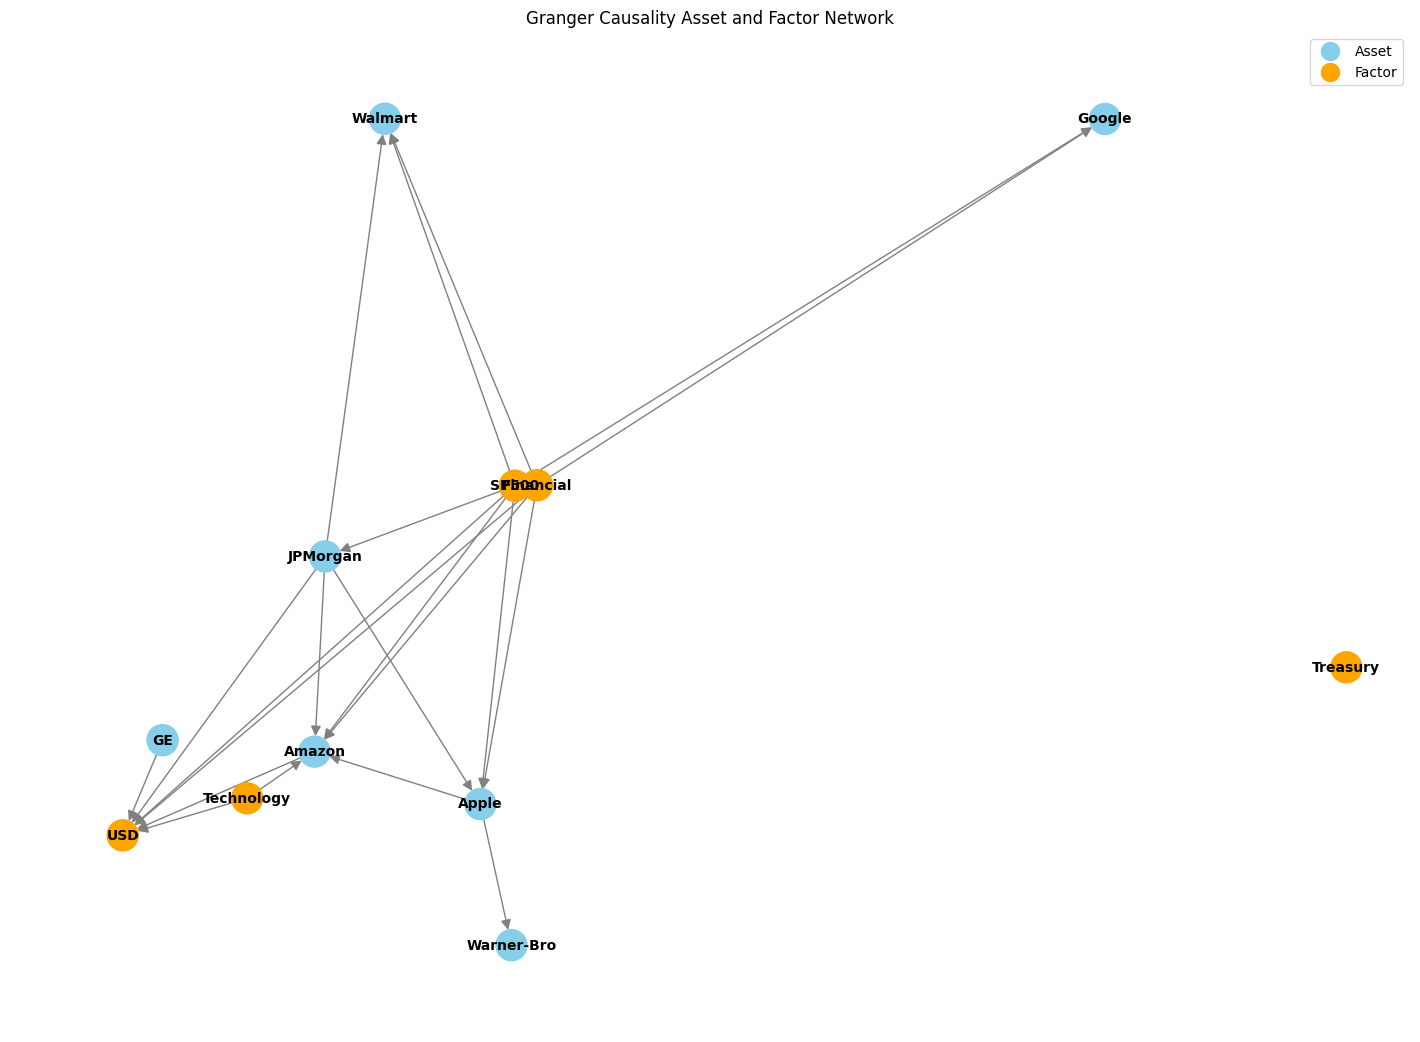

In [16]:
# Create and visualize the network

# Assign types to nodes
node_types = {
    'Apple':'Asset',
    'Amazon':'Asset',
    'USD':'Factor',
    'GE':'Asset',
    'Google':'Asset',
    'JPMorgan':'Asset',
    'Treasury':'Factor',
    'Warner-Bro':'Asset',
    'Walmart':'Asset',
    'Financial':'Factor',
    'Technology':'Factor',
    'SP500':'Factor',
}

nx.set_node_attributes(G, node_types, 'type')

# Draw the network graph
plt.figure(figsize=(14, 10))

# Use different colors for assets and factors
node_colors = ['skyblue' if G.nodes[name]['type'] == 'Asset' else 'orange' for name in G.nodes()]

# Create layout
pos = nx.spring_layout(G, seed=42)

# Draw the network
nx.draw(G, pos,
        with_labels=True,
        node_size=500,
        node_color=node_colors,
        font_size=10,
        font_weight='bold',
        edge_color='gray',
        arrows=True,
        arrowsize=15)

# Add a legend
asset_patch = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='skyblue',
                       markersize=15, label='Asset')
factor_patch = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='orange',
                        markersize=15, label='Factor')
plt.legend(handles=[asset_patch, factor_patch], loc='upper right')

plt.title('Granger Causality Asset and Factor Network')
plt.show()

The above network graph provides some interesting Granger causality test results. From the graph, we can see SP500 and Financial ETFs Granger-cause all the stock returns except GE and Warner Brothers. One interesting observation is that several stocks also Granger-cause USD ETF. For example, not only does the SP500 Granger-cause USD ETF, Amazon also Granger-causes USD ETF. There might be a spurious relationship going on here. As we discussed before, the Granger causality test in bivariate VAR model setting can have no confounding variable issue. In the above graph, we see SP500 Granger-causes USD ETF. SP500 also Granger-causes Amazon. Then Amazon also Granger-causes USD ETF. SP500 might be the confounding variable when we conduct Granger causality test between Amazon and USD ETF. Let's check on that by running the following 3 variable VAR model. As before, we will find the optimal lag order and fit the model. Once the model is fitted, we can conduct the Granger causality test.

In [15]:
# Create a dataset to run the VAR model
gc_data = returns[["Amazon","SP500","USD"]]

# Use select_order to find the optimal lag order
model = VAR(gc_data)
lag_order_results = model.select_order(maxlags=10)
lag_order = lag_order_results.aic # You can also use bic, fpe or hqic
# Fit the VAR model
model_fitted = model.fit(lag_order)

In [16]:
# Perform Granger causality test on JPMorgan Granger causes Technology; the test statistic is F-test
test_result = model_fitted.test_causality(caused='USD', causing='Amazon',kind='f')
print(test_result.summary())

Granger causality F-test. H_0: Amazon does not Granger-cause USD. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value     df   
-----------------------------------------------
         1.673          1.882   0.090 (9, 5166)
-----------------------------------------------


From the above Granger causality test result, we see that p value is 0.09 and we cannot reject $H_0$ and the result is Amazon does not Granger-cause USD ETF. This is the example how omitting a confounding variable can change the result of Granger causality test. In the recent research advance, searchers have proposed several modifications to handle no confounding variable issue. We will not cover them in this lesson. For those who are interested, there is plenty information online. 
### **5. Conclusion**
In this lesson, we learned the differences between association and causality. Then we introduced Granger causality and went through its theory. We also discussed the assumptions and limitations of Granger causality. Finally we combined Granger causality and network theory to produce a Granger causality based network. This complex network can help us to better understand the Granger causal relationship among assets and factors.

### **References**
1. Nicolae et al, "Part I: Exploring Data, 10. Data Collection, Causality and Association", Introduction to Data Science, University of Chicago, 2022, https://ds1.datascience.uchicago.edu/10/data-collection.html
2. Hansen "Conditional Expectation and Projection: Causal Effect ", Econometrics, University of Wisconsin, 2014, pp. 43
3. Billio, M., Getmansky, M., Lo, A. W. and L. Pelizzon. (2012) Econometric measures of connectedness and systemic risk in the finance and insurance sectors. Journal of Financial Economics, 104(3), pp. 535–559.

______
Copyright 2025 WorldQuant University. This content is licensed solely for personal use. Redistribution or publication of this material is strictly prohibited.